#Assignment-9

**Aim**- Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow.

**Theory**

A Data Science pipeline is a structured process used to convert raw data into meaningful insights through steps like data collection, cleaning, analysis, and modeling. It ensures an organized and efficient workflow.

The pipeline begins with Data Ingestion, where data is collected and loaded into a DataFrame. Then Data Cleaning is performed to handle missing values and ensure data quality using functions like isnull().

Next, Data Wrangling transforms data and creates new features. Exploratory Data Analysis (EDA) is used to understand patterns using visualizations like scatter plots and histograms.

After that, Correlation Analysis measures relationships between variables using Karl Pearson’s coefficient. Feature Selection and Scaling help in choosing important variables and normalizing data.

Finally, Model Building and Evaluation is done using linear regression, and performance is measured using MSE and R² score.


Data Loaded:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


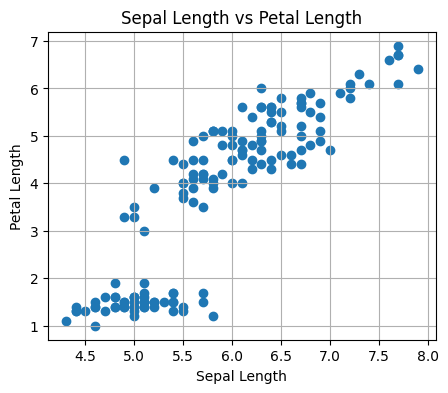

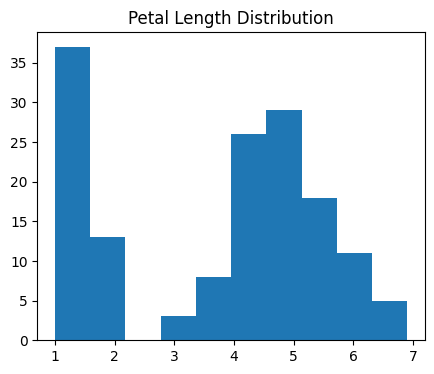


Karl Pearson Correlation Coefficient: 0.8718

Regression Equation: y = 1.53 x + 3.76
Mean Squared Error (MSE): 0.7431
R² Score: 0.76


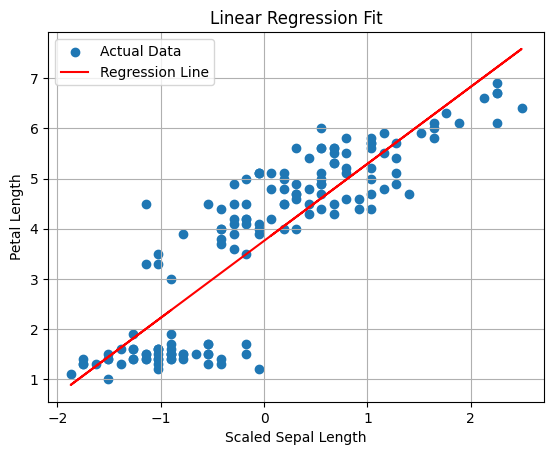

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("Data Loaded:")
print(df.head())

print("\nMissing Values:\n", df.isnull().sum())

df['petal_area'] = df['petal length (cm)'] * df['petal width (cm)']

plt.figure(figsize=(5,4))
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'])
plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.grid(True)
plt.show()

plt.figure(figsize=(5,4))
plt.hist(df['petal length (cm)'], bins=10)
plt.title("Petal Length Distribution")
plt.show()

corr = np.corrcoef(df['sepal length (cm)'], df['petal length (cm)'])[0,1]
print("\nKarl Pearson Correlation Coefficient:", round(corr,4))

X = df[['sepal length (cm)']]
y = df['petal length (cm)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nRegression Equation: y =", round(model.coef_[0],2), "x +", round(model.intercept_,2))
print("Mean Squared Error (MSE):", round(mse,4))
print("R² Score:", round(r2,4))

plt.scatter(X_scaled, y, label="Actual Data")
plt.plot(X_scaled, y_pred, color='red', label="Regression Line")
plt.xlabel("Scaled Sepal Length")
plt.ylabel("Petal Length")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

**1. What is a Data Science pipeline? Explain its key stages with examples.**

A Data Science pipeline is a structured sequence of steps used to collect, process, analyze, and model data to extract meaningful insights or make predictions. It ensures that raw data is transformed into useful information in a systematic and efficient manner.

Based on your previous practicals (data ingestion, cleaning, wrangling, visualization, and modeling), a typical pipeline includes:

Data Ingestion: Collecting data from sources such as CSV files, APIs, or web scraping. For example, loading the Titanic dataset using pandas.read_csv() as done in Assignment 2 .
Data Cleaning: Handling missing values, duplicates, and inconsistencies using functions like isnull(), dropna(), and fillna() as performed in your data cleaning practical .
Data Wrangling / Transformation: Structuring and transforming data, such as creating new columns like “Status” based on scores in Assignment 3 .
Exploratory Data Analysis (EDA): Understanding data using statistics and visualizations like scatter plots, histograms, and box plots using Matplotlib and Seaborn .
Feature Engineering: Creating meaningful features to improve model performance.
Model Building: Applying algorithms such as linear regression (Assignment 8).
Evaluation: Measuring model performance using metrics like MSE and R².

Thus, a data science pipeline connects all steps into a complete workflow from raw data to final insights.

**2. What is Exploratory Data Analysis (EDA)? How do univariate and bivariate analyses help in understanding the dataset?**

Exploratory Data Analysis (EDA) is the process of analyzing and summarizing a dataset to understand its main characteristics before applying machine learning models. It helps in identifying patterns, detecting outliers, and checking data quality.

According to your practical, EDA uses visualization and statistical techniques to simplify complex data and support decision-making .

Univariate Analysis:
It analyzes a single variable at a time. It helps understand distribution, central tendency, and spread of data.
Example: Histogram of petal length in the iris dataset (Assignment 5) .
Bivariate Analysis:
It analyzes the relationship between two variables. It helps identify correlation or patterns between variables.
Example: Scatter plot of sepal length vs sepal width to observe relationships .

EDA is important because it helps in making informed decisions before building models.

**3. Differentiate between Label Encoding and One-Hot Encoding. When should each be used?**

Label Encoding and One-Hot Encoding are techniques used to convert categorical data into numerical form so that machine learning models can process it.

Label Encoding:
Assigns a unique integer to each category.
Example: Male = 0, Female = 1.
Use: When categories have an inherent order (e.g., Low, Medium, High).
One-Hot Encoding:
Converts categories into multiple binary columns (0 or 1).
Example: Male → [1, 0], Female → [0, 1].
Use: When categories are nominal (no order), to avoid misleading relationships.

Thus, label encoding is simple but may introduce false relationships, while one-hot encoding preserves independence between categories.

**4. Why is feature scaling required? Compare normalization and standardization.**

Feature scaling is the process of adjusting the range of data values so that all features contribute equally to the model. It is important because many machine learning algorithms are sensitive to the scale of data.

Normalization (Min-Max Scaling):
Scales data to a fixed range, usually 0 to 1.

Formula:

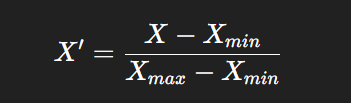

Use: When data does not follow a normal distribution.


Standardization (Z-score Scaling):
Transforms data to have mean = 0 and standard deviation = 1.

Formula:

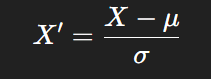X

Use: When data follows a normal distribution.

Normalization is useful for bounded data, while standardization is preferred for most machine learning models.

**5. What is feature engineering? Explain how creating new features can improve model performance.**

Feature engineering is the process of creating new input features or modifying existing ones to improve the performance of machine learning models.

In your data wrangling practical, a new column “Status” was created based on score values, which is an example of feature engineering .

Creating new features improves model performance because:

It provides more meaningful information to the model
It helps capture hidden patterns in data
It improves prediction accuracy
It reduces noise and redundancy

Example:
Instead of using “Date” directly, extracting “Month” or “Day” can help the model understand seasonal patterns better.

**Conclusion**

In this assignment, a complete Data Science pipeline was implemented by combining all previously learned techniques. The process included data ingestion, cleaning, wrangling, visualization, correlation, and regression.

The pipeline demonstrated how raw data can be transformed into meaningful insights through a structured approach. Overall, it highlights the importance of proper data processing and modeling in achieving accurate and reliable results.